In [15]:
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt


df_players = pd.read_csv("Base_Cadastral_de_Players.csv", sep=";")
df_transacoes = pd.read_csv("Base_de_Transacoes_e_Cupons_Capturados.csv", sep=";")
df_lojas = pd.read_csv("Base_Massa_de_Teste_com_Lojas_e_Valores.csv", sep=";")
df_simulacao = pd.read_csv("Base_Simulada_-_Pedestres_Av__Paulista.csv", sep=";")

dfs = {"Players":df_players, 
       "Transaçôes":df_transacoes, 
       "Simulação":df_simulacao, 
       "Lojas":df_lojas}

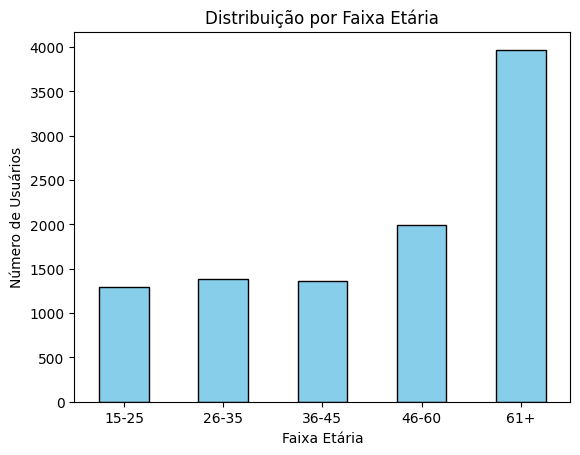

In [16]:

df_players["data_nascimento"] = pd.to_datetime(df_players["data_nascimento"], format="%d/%m/%Y", errors="coerce")
hoje = pd.to_datetime(date.today())

df_players["idade"] = (
    hoje.year - df_players["data_nascimento"].dt.year
    - ((hoje.month < df_players["data_nascimento"].dt.month) |
       ((hoje.month == df_players["data_nascimento"].dt.month) &
        (hoje.day < df_players["data_nascimento"].dt.day)))
)

media_idade = df_players["idade"].mean()
maior_idade = df_players["idade"].max()
menor_idade = df_players["idade"].min()

bins = [15, 25, 35, 45, 60, 100]  
labels = ["15-25", "26-35", "36-45", "46-60", "61+"]

df_players["faixa_etaria"] = pd.cut(df_players["idade"], bins=bins, labels=labels, right=True)

faixa_counts = df_players["faixa_etaria"].value_counts().sort_index()

faixa_counts.plot(kind="bar", edgecolor="black", color="skyblue")
plt.title("Distribuição por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Número de Usuários")
plt.xticks(rotation=0)
plt.show()
